<a href="https://colab.research.google.com/github/sarbanibhadra/NLP_Similariry_Analysis/blob/main/Group118_UNGeneralDebates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing
# Assignment – 1: Set-12

**Student Name:**  
MAGESH KUMAR S - 2025ag05112@wilp.bits-pilani.ac.in, \
SARBANI DAS - 2025ag05587@wilp.bits-pilani.ac.in, \
NITIN TU - 2025ag05410@wilp.bits-pilani.ac.in, \
ASHUTOSH TIWARI - 2025ag05588@wilp.bits-pilani.ac.in

**Group:** 118  
**Assignment Dataset:** United Nations General Debate Corpus  

### Objective
Part I - Sentence completion with a Bigram (N-gram) model  
Part II (i) - Text preprocessing (tokenize, lowercase, stop words, stem, lemmatize)  
Part II (ii) - Word embeddings using Skip-Gram (Word2Vec)  
Part II (iii) - Similarity analysis + 2D PCA visualisation  

**About the dataset:** It has 7,507 speeches given by countries at the UN General Assembly (1970–2015). Columns: `session`, `year`, `country`, `text`. Each speech is treated as one *document*.

## Import libraries and load the data

In [1]:
# Installing missing packages
import sys
import importlib
import subprocess

IN_COLAB = "google.colab" in sys.modules


def ensure_package(pip_spec, import_name):
    '''Install a package with pip only if it cannot already be imported.'''
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Installing {pip_spec} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_spec])

for pip_spec, import_name in [("gensim>=4.4.0", "gensim"),
                              ("nltk", "nltk"),
                              ("scikit-learn", "sklearn"),
                              ("pandas", "pandas"),
                              ("matplotlib", "matplotlib")]:
    ensure_package(pip_spec, import_name)

print("Running in Google Colab" if IN_COLAB else "Running in a local Jupyter environment")

Installing gensim>=4.4.0 ...
Running in Google Colab


In [2]:
# Importing the necessary files
import re, sys, time, zipfile, os
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

for pkg in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

In [3]:
# Imports, folders and reproducibility settings ----
import os
import re
import time
import random
import shutil
import zipfile
import urllib.request
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

import gensim
from gensim.models import Word2Vec

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# All paths are relative to the notebook's working directory
# (the notebook folder locally, /content in Colab).
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"          # the input CSV are placed here
OUTPUT_DIR = BASE_DIR / "outputs"     # figures and result tables
MODEL_DIR = BASE_DIR / "models"       # trained Word2Vec model
for folder in (DATA_DIR, OUTPUT_DIR, MODEL_DIR):
    folder.mkdir(exist_ok=True)

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"nltk {nltk.__version__} | gensim {gensim.__version__} | scikit-learn {sklearn.__version__}")
print("Working directory:", BASE_DIR)

Python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | nltk 3.9.1 | gensim 4.4.0 | scikit-learn 1.6.1
Working directory: /content


In [4]:
# Locate (or download / upload) the dataset, then load it
import os
DATASET_FILE = "un-general-debates.csv"
DATASET_URL = "https://www.kaggle.com/api/v1/datasets/download/unitednations/un-general-debates"
SEARCH_DIRS = [BASE_DIR, DATA_DIR, Path("/content"), Path("/content/drive/MyDrive")]

def find_local_dataset():
    '''Return the path of the CSV if it exists locally, extracting it from a zip if necessary.'''
    for folder in SEARCH_DIRS:
        if (folder / DATASET_FILE).is_file():
            return folder / DATASET_FILE
    for folder in SEARCH_DIRS:
        if not folder.is_dir():
            continue
        for archive in sorted(folder.glob("*.zip")):
            print(f"Trying {archive.name} ...")
            try:
                with zipfile.ZipFile(archive) as zf:
                    members = [m for m in zf.namelist() if m.endswith(DATASET_FILE)]
                    if members:
                        with zf.open(members[0]) as src, open(DATA_DIR / DATASET_FILE, "wb") as dst:
                            shutil.copyfileobj(src, dst)
                        print(f"Extracted {DATASET_FILE} from {archive.name}")
                        return DATA_DIR / DATASET_FILE
            except zipfile.BadZipFile:
                continue
    return None


def download_dataset():
    '''Try the Kaggle link from the assignment. Returns True if a zip was saved.'''
    target = DATA_DIR / "un-general-debates.zip"
    try:
        print("Dataset not found locally. Trying the Kaggle download link ...")
        with urllib.request.urlopen(DATASET_URL, timeout=60) as response, open(target, "wb") as out:
            shutil.copyfileobj(response, out)
        return zipfile.is_zipfile(target)
    except Exception as exc:
        print(f"Download failed: {exc}")
        target.unlink(missing_ok=True)
        return False


def locate_dataset():
    path = find_local_dataset()
    if path is None and download_dataset():
        path = find_local_dataset()
    if path is None:
        raise FileNotFoundError(
            f"{DATASET_FILE} was not found. Place it next to this notebook or in {DATA_DIR}.")
    return path


csv_path = locate_dataset()
df = pd.read_csv(csv_path)
print(f"Loaded {csv_path}  ->  {df.shape[0]:,} speeches, {df.shape[1]} columns")
df.head()

Dataset not found locally. Trying the Kaggle download link ...
Trying un-general-debates.zip ...
Extracted un-general-debates.csv from un-general-debates.zip
Loaded /content/data/un-general-debates.csv  ->  7,507 speeches, 4 columns


,session,year,country,text
0,44,1989,MDV,﻿It is indeed a pleasure for me and the members of my delegation to extend to Ambassador Garba our sincere congratul...
1,44,1989,FIN,"﻿\nMay I begin by congratulating you. Sir, on your election to the presidency of the General Assembly at its forty-f..."
2,44,1989,NER,"﻿\nMr. President, it is a particular pleasure for me, on behalf of the delegation of Niger, to congratulate you moat..."
3,44,1989,URY,"﻿\nDuring the debate at the fortieth session of the General Assembly four years ago, President Sanguinetti announced..."
4,44,1989,ZWE,"﻿I should like at the outset to express my delegation's satisfaction and pleasure at your election, Sir, to the pres..."


In [5]:
# Printing the stats
print(df.isnull().sum())
print("Number of speeches:", len(df))
print("Average speech length (characters):", int(df['text'].str.len().mean()))
print("Year range:", int(df["year"].min()), "to", int(df["year"].max()))
print("Number of different countries:", df['country'].nunique())

session    0
year       0
country    0
text       0
dtype: int64
Number of speeches: 7507
Average speech length (characters): 17967
Year range: 1970 to 2015
Number of different countries: 199


---
# PART I – Sentence Completion using N-gram (Bigram) model

A **bigram model** looks at only the *previous one word* to guess the next word.  
For the test sentence **"it is a pleasure ____"** the last word is **"pleasure"**, so we ask:  
*"In the whole corpus, which words most often come right after 'pleasure'?"*

The probability is estimated by counting:

$$P(w_2 \mid w_1) = \frac{Count(w_1, w_2)}{Count(w_1)}$$

**Steps:** (1) tokenize + lowercase all speeches, (2) count unigrams and bigrams over the **whole dataset**, (3) find the top 3 words after "pleasure".

In [6]:
# ---- Tokenizer ----
# This regex keeps only alphabetic words (drops numbers, punctuation and the hidden BOM character at the start of some speeches).
tokenizer = RegexpTokenizer(r"[A-Za-z]+")

def tokenize_lower(text):
    # split into words and lowercase them
    return [w.lower() for w in tokenizer.tokenize(text)]

# Small demo on one sentence
print(tokenize_lower("It is indeed a pleasure for me, Mr. President!"))

['it', 'is', 'indeed', 'a', 'pleasure', 'for', 'me', 'mr', 'president']


In [7]:
# Count unigrams and bigrams over ALL speeches
unigram_counts = Counter()
bigram_counts = Counter()

start = time.time()
for text in df['text']:
    tokens = tokenize_lower(text)
    unigram_counts.update(tokens)
    # zip(tokens, tokens[1:]) makes pairs of neighbouring words = bigrams
    # (bigrams are made inside each speech, so no pair crosses two different speeches)
    bigram_counts.update(zip(tokens, tokens[1:]))

print("Total words in corpus  :", sum(unigram_counts.values()))
print("Unique words           :", len(unigram_counts))
print("Unique bigrams         :", len(bigram_counts))
print("Time taken             : %.1f sec" % (time.time() - start))

Total words in corpus  : 21525588
Unique words           : 50909
Unique bigrams         : 1788490
Time taken             : 31.8 sec


In [8]:
# Function that recommends next words
def recommend_next_words(sentence, top_n=3):
    # last word of the sentence is the context for a bigram model
    last_word = tokenize_lower(sentence)[-1]
    total_last = unigram_counts[last_word]

    if total_last == 0:
        print("Word '%s' not found in corpus" % last_word)
        return []

    # collect all bigrams that start with last_word
    candidates = {w2: c for (w1, w2), c in bigram_counts.items() if w1 == last_word}

    # sort by count and keep the best top_n
    best = sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:top_n]

    print("Context word (w1):", last_word, "| Count(w1) =", total_last)
    print("-" * 60)
    results = []
    for w2, c in best:
        prob = c / total_last          # P(w2 | w1)
        results.append((w2, c, prob))
        print("%-12s bigram count = %-6d P(%s | %s) = %.4f" % (w2, c, w2, last_word, prob))
    return results

test_sentence = "it is a pleasure"
top3 = recommend_next_words(test_sentence, top_n=3)

Context word (w1): pleasure | Count(w1) = 2225
------------------------------------------------------------
to           bigram count = 750    P(to | pleasure) = 0.3371
for          bigram count = 290    P(for | pleasure) = 0.1303
in           bigram count = 269    P(in | pleasure) = 0.1209


In [9]:
# Show the completed sentences
print("Test sentence:", test_sentence, "____")
print()
for rank, (w, c, p) in enumerate(top3, start=1):
    print("Option %d: %s %s   (probability = %.2f%%)" % (rank, test_sentence, w, p * 100))

Test sentence: it is a pleasure ____

Option 1: it is a pleasure to   (probability = 33.71%)
Option 2: it is a pleasure for   (probability = 13.03%)
Option 3: it is a pleasure in   (probability = 12.09%)


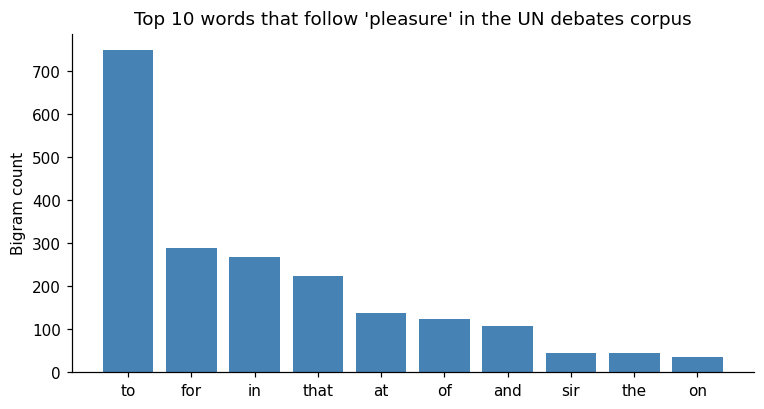

In [10]:
# Small bar chart of top 10 words after 'pleasure'
cands = {w2: c for (w1, w2), c in bigram_counts.items() if w1 == 'pleasure'}
top10 = sorted(cands.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top10)

plt.figure(figsize=(8, 4))
plt.bar(words, counts, color='steelblue')
plt.title("Top 10 words that follow 'pleasure' in the UN debates corpus")
plt.ylabel("Bigram count")
plt.show()

### Part I – Observation
The model recommends the three words above because they have the **highest bigram counts after "pleasure"**. Since UN speeches often start with phrases such as *"It is a pleasure to congratulate the President..."*, the word **"to"** is most likely, which is grammatically correct as well ("pleasure **to** ..."). The other words (like *for*, *in*) also form common phrases ("pleasure for me", "pleasure in ...").

  ---
   # PART II – Preprocessing, Feature Extraction and Similarity

   ## (i) Text Preprocessing

   Steps applied to every speech, in this order:
   1. **Tokenization** – split the text into words.
   2. **Lowercasing** – "Nations" and "nations" become the same word.
   3. **Stop word removal** – remove very common words (the, is, of...) that carry little meaning. We also drop tokens shorter than 3 letters (left-overs like "s", "t" from "don't", "it's").
   4. **Stemming** (Porter) – cut words to a root, e.g. *nations → nation*, *developing → develop*. Fast but the result may not be a real word (e.g. *countries → countri*).
   5. **Lemmatization** (WordNet) – convert words to their dictionary form, e.g. *countries → country*.

Note: Stemming and lemmatization are two alternative normalization methods applied to the *same cleaned tokens* (after tokenization, lowercasing, and stop-word removal). For this analysis, the lemmatized version of the tokens will be used in subsequent steps.

In [11]:
# Preprocessing the text
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

sample = "The countries are developing new nations and the Delegations were discussing peaceful solutions."

tokens = tokenizer.tokenize(sample)                                   # 1. tokenization
lower = [t.lower() for t in tokens]                                   # 2. lowercasing
no_stop = [t for t in lower if t not in stop_words and len(t) > 2]    # 3. stop word removal
stemmed = [stemmer.stem(t) for t in no_stop]                          # 4. stemming
lemmas = [lemmatizer.lemmatize(t) for t in no_stop]                   # 5. lemmatization

print("1. Tokens     :", tokens)
print("2. Lowercase  :", lower)
print("3. No stopwords:", no_stop)
print("4. Stemmed    :", stemmed)
print("5. Lemmatized :", lemmas)

1. Tokens     : ['The', 'countries', 'are', 'developing', 'new', 'nations', 'and', 'the', 'Delegations', 'were', 'discussing', 'peaceful', 'solutions']
2. Lowercase  : ['the', 'countries', 'are', 'developing', 'new', 'nations', 'and', 'the', 'delegations', 'were', 'discussing', 'peaceful', 'solutions']
3. No stopwords: ['countries', 'developing', 'new', 'nations', 'delegations', 'discussing', 'peaceful', 'solutions']
4. Stemmed    : ['countri', 'develop', 'new', 'nation', 'deleg', 'discuss', 'peac', 'solut']
5. Lemmatized : ['country', 'developing', 'new', 'nation', 'delegation', 'discussing', 'peaceful', 'solution']


### Apply the pipeline to the whole dataset
Stemming/lemmatizing millions of words one by one is slow. Many words repeat, so we use a **cache (dictionary)**: each unique word is stemmed/lemmatized only once and the result is reused. This gives the same output, just faster.

In [12]:
# Caches so each unique word is processed only once
stem_cache, lemma_cache = {}, {}

def get_stem(w):
    if w not in stem_cache:
        stem_cache[w] = stemmer.stem(w)
    return stem_cache[w]

def get_lemma(w):
    if w not in lemma_cache:
        lemma_cache[w] = lemmatizer.lemmatize(w)
    return lemma_cache[w]

def preprocess(text):
    tokens = tokenizer.tokenize(text)                                     # 1. tokenization
    tokens = [t.lower() for t in tokens]                                  # 2. lowercasing
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]    # 3. stop word removal
    stems = [get_stem(t) for t in tokens]                                 # 4. stemming
    lemmas = [get_lemma(t) for t in tokens]                               # 5. lemmatization
    return tokens, stems, lemmas

clean_tokens, stem_docs, lemma_docs = [], [], []
start = time.time()
for text in df['text']:
    t, s, l = preprocess(text)
    clean_tokens.append(t)
    stem_docs.append(s)
    lemma_docs.append(l)

print("Documents processed: ", len(lemma_docs))
print("Tokens after cleaning:", sum(len(d) for d in lemma_docs))
print("Time taken: %.1f sec" % (time.time() - start))

Documents processed:  7507
Tokens after cleaning: 11173513
Time taken: 25.5 sec


In [13]:
# ---- Look at one speech: before vs after preprocessing ----
i = 0
print("ORIGINAL (first 300 chars):\n", df['text'][i][:300].replace("\n", " "))
print("\nAFTER STOPWORD REMOVAL (first 25 tokens):\n", clean_tokens[i][:25])
print("\nSTEMMED (first 25 tokens):\n", stem_docs[i][:25])
print("\nLEMMATIZED (first 25 tokens):\n", lemma_docs[i][:25])

ORIGINAL (first 300 chars):
 ﻿It is indeed a pleasure for me and the members of my delegation to extend to Ambassador Garba our sincere congratulations on his election to the presidency of the forty-fourth session of the General Assembly. His election to this high office is a well-deserved tribute to his personal qualities and 

AFTER STOPWORD REMOVAL (first 25 tokens):
 ['indeed', 'pleasure', 'members', 'delegation', 'extend', 'ambassador', 'garba', 'sincere', 'congratulations', 'election', 'presidency', 'forty', 'fourth', 'session', 'general', 'assembly', 'election', 'high', 'office', 'well', 'deserved', 'tribute', 'personal', 'qualities', 'experience']

STEMMED (first 25 tokens):
 ['inde', 'pleasur', 'member', 'deleg', 'extend', 'ambassador', 'garba', 'sincer', 'congratul', 'elect', 'presid', 'forti', 'fourth', 'session', 'gener', 'assembl', 'elect', 'high', 'offic', 'well', 'deserv', 'tribut', 'person', 'qualiti', 'experi']

LEMMATIZED (first 25 tokens):
 ['indeed', 'pleasure', 'me

In [14]:
# ---- Compare vocabulary size at each step ----
vocab_clean = set(w for d in clean_tokens for w in d)
vocab_stem = set(w for d in stem_docs for w in d)
vocab_lemma = set(w for d in lemma_docs for w in d)

comparison = pd.DataFrame({
    'Step': ['After stop word removal', 'After stemming', 'After lemmatization'],
    'Unique words': [len(vocab_clean), len(vocab_stem), len(vocab_lemma)]
})
comparison

,Step,Unique words
0,After stop word removal,50385
1,After stemming,30654
2,After lemmatization,44486


### Observation
- Stemming shrinks the vocabulary the most, but it produces non-words.
- Lemmatization shrinks it less, but every word stays a real, readable word.
- **Limitation of Lemmatization:** `WordNetLemmatizer` defaults to treating words as nouns. Without providing a Part-of-Speech (POS) tag, it won't lemmatize verbs or adjectives (e.g., 'developing', 'discussing', 'deserved') to their base forms (e.g., 'develop', 'discuss', 'deserve').

**Choice for the next step:** we train the embeddings on the **lemmatized tokens**, because real words are easier to read and interpret in the similarity results and in the plots.

## (ii) Feature Extraction – Word Embedding using Skip-Gram

**Skip-Gram (Word2Vec)** trains a small neural network to predict the *surrounding words* (context) from a *centre word*. Words that appear in similar contexts get similar vectors. Unlike Bag-of-Words/TF-IDF, embeddings capture *meaning*, e.g. *poverty* will be close to *hunger*.

Important parameters (`sg=1` selects Skip-Gram):

| Parameter | Value | Meaning |
|---|---|---|
| `vector_size` | 100 | length of each word vector |
| `window` | 5 | how many words left/right count as context |
| `min_count` | 5 | ignore very rare words (they do not have enough examples to learn from) |
| `sg` | 1 | Skip-Gram (0 would be CBOW) |
| `epochs` | 5 | number of passes over the data |
| `negative` | 10 | how many "noise words" should be drawn (negative sampling) |
| `sample` | 1e-4 | threshold for configuring which higher-frequency words are randomly downsampled |

The trained model is saved in models/. Set RETRAIN = False to reload it instead of training again on a rerun.

In [15]:
# ---- Train or reload the Skip-Gram model on the lemmatized speeches ----
RETRAIN = True
MODEL_PATH = MODEL_DIR / "skipgram_un_debates.model"

if MODEL_PATH.exists() and not RETRAIN:
    w2v = Word2Vec.load(str(MODEL_PATH))
    print("Loaded saved model from", MODEL_PATH)
else:
    start = time.time()
    w2v = Word2Vec(sentences=lemma_docs, sg=1, vector_size=100, window=5, min_count=5,
                   negative=10, sample=1e-4, epochs=5, seed=SEED,
                   workers=max(1, (os.cpu_count() or 2) - 1))
    w2v.save(str(MODEL_PATH))
    RETRAIN = False
    print(f"Trained skip-gram model in {time.time() - start:.0f} s and saved it to {MODEL_PATH}")

print(f"Embedding matrix: {w2v.wv.vectors.shape[0]:,} words x {w2v.wv.vector_size} dimensions")
print("Vocabulary size of the model:", len(w2v.wv))
print("Training time: %.1f sec" % (time.time() - start))

Trained skip-gram model in 529 s and saved it to /content/models/skipgram_un_debates.model
Embedding matrix: 21,552 words x 100 dimensions
Vocabulary size of the model: 21552
Training time: 528.8 sec


In [16]:
# ---- Quick check: do the vectors make sense ----
for word in ['peace', 'poverty', 'nuclear', 'terrorism']:
    print(word, "->", [(w, round(s, 3)) for w, s in w2v.wv.most_similar(word, topn=5)])
    print()

peace -> [('stability', 0.768), ('security', 0.75), ('lasting', 0.724), ('durable', 0.719), ('maintenance', 0.693)]

poverty -> [('hunger', 0.881), ('illiteracy', 0.817), ('underdevelopment', 0.81), ('destitution', 0.798), ('abject', 0.792)]

nuclear -> [('weapon', 0.887), ('proliferation', 0.788), ('nonproliferation', 0.775), ('nonnuclear', 0.773), ('npt', 0.77)]

terrorism -> [('terrorist', 0.787), ('extremism', 0.77), ('daesh', 0.724), ('combated', 0.721), ('radicalization', 0.714)]



The neighbours make sense (words about the same topic are close), so the embeddings were learned properly.

### Making one vector per document
Skip-Gram gives a vector per *word*, but we need to compare *documents*. Simple and common solution: **average the word vectors of all words in the document** (mean pooling). Each speech then becomes one 100-dimensional vector.

In [17]:
# ---- Document vector = average of the word vectors in that document ----
def doc_vector(tokens):
    vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]   # skip words not in vocabulary
    if len(vecs) == 0:
        return np.zeros(w2v.vector_size)
    return np.mean(vecs, axis=0)

doc_vectors = np.array([doc_vector(d) for d in lemma_docs])
print("Document vector matrix shape:", doc_vectors.shape, "(documents x dimensions)")

Document vector matrix shape: (7507, 100) (documents x dimensions)


## (iii) Similarity Analysis

### Choice of similarity metric: **Cosine similarity**
$$cos(A,B) = \frac{A \cdot B}{\|A\| \, \|B\|}$$

**Why cosine?**
- It compares the **direction** of the vectors, not their length. Long and short speeches get averaged vectors of different magnitudes, and cosine ignores this so length does not distort the result.
- It is the standard metric for embedding and text vectors, and gives values between -1 and 1 that are easy to read.
- Euclidean distance would be affected by vector length, so it is less suitable here.

### Feature design justification
- **Skip-Gram** works well for a large corpus and for rarer words/topics such as *disarmament* or *apartheid*.
- **Averaging** gives a fixed-size vector for documents of any length.
- **Mean-centering:** all UN speeches share general themes (peace, nations, development), so raw averaged vectors are nearly identical. Subtracting the average document vector keeps only what makes each speech different, which spreads the scores out and makes them more meaningful.

In [18]:
# ---- Mean-centre the document vectors, then normalise to unit length ----
centered = doc_vectors - doc_vectors.mean(axis=0)
norms = np.linalg.norm(centered, axis=1, keepdims=True)
norms[norms == 0] = 1
unit_vectors = (centered / norms).astype(np.float32)
sim_matrix = unit_vectors @ unit_vectors.T
print("Similarity matrix shape:", sim_matrix.shape)
doc_names = (df['country'].astype(str) + "_" + df['year'].astype(str)).tolist()

Similarity matrix shape: (7507, 7507)


In [19]:
# ---- Find the TOP 10 most similar pairs of documents in the whole dataset ----
# We look only at the upper triangle (k=1) so we do not count (A,B) and (B,A) twice
# and we do not compare a document with itself.
upper = np.triu(sim_matrix, k=1)

flat_idx = np.argsort(upper, axis=None)[::-1][:10]
rows, cols = np.unravel_index(flat_idx, upper.shape)

print("TOP 10 MOST SIMILAR DOCUMENT PAIRS")
print("=" * 60)
for rank, (r, c) in enumerate(zip(rows, cols), start=1):
    print("Rank %d: %s   <-->   %s" % (rank, doc_names[r], doc_names[c]))
    print("        Cosine similarity = %.4f" % sim_matrix[r, c])

TOP 10 MOST SIMILAR DOCUMENT PAIRS
Rank 1: ZAF_1984   <-->   CAF_1984
        Cosine similarity = 0.9986
Rank 2: ALB_1983   <-->   ALB_1982
        Cosine similarity = 0.9828
Rank 3: KHM_1979   <-->   KHM_1980
        Cosine similarity = 0.9812
Rank 4: VNM_1982   <-->   VNM_1980
        Cosine similarity = 0.9790
Rank 5: VNM_1979   <-->   VNM_1980
        Cosine similarity = 0.9779
Rank 6: ALB_1975   <-->   ALB_1978
        Cosine similarity = 0.9777
Rank 7: KHM_1984   <-->   KHM_1983
        Cosine similarity = 0.9765
Rank 8: RUS_1976   <-->   RUS_1977
        Cosine similarity = 0.9759
Rank 9: MNG_1980   <-->   MNG_1981
        Cosine similarity = 0.9743
Rank 10: VNM_1982   <-->   VNM_1981
        Cosine similarity = 0.9736


In [20]:
# ---- Function: top 2 documents most similar to any chosen document ----
def top_similar_docs(index, k=2):
    scores = sim_matrix[index].copy()
    scores[index] = -1
    best = np.argsort(scores)[::-1][:k]
    print("Query document:", doc_names[index])
    for rank, b in enumerate(best, start=1):
        print("  Top %d similar: %-12s (cosine = %.4f)" % (rank, doc_names[b], scores[b]))

# Example: use the first document and two others
for idx in [0, 100, 2500]:
    top_similar_docs(idx)
    print()

Query document: MDV_1989
  Top 1 similar: MDV_1988     (cosine = 0.7077)
  Top 2 similar: KNA_1988     (cosine = 0.6504)

Query document: PAK_1989
  Top 1 similar: PAK_1990     (cosine = 0.8406)
  Top 2 similar: PAK_1979     (cosine = 0.8157)

Query document: ZWE_1984
  Top 1 similar: ETH_1984     (cosine = 0.8559)
  Top 2 similar: MLI_1978     (cosine = 0.8131)



In [26]:
# ---- Check the result: compare the words of the most similar pair without duplicate data check----

r, c = rows[0], cols[0]
common = set(lemma_docs[r]) & set(lemma_docs[c])
print("Best pair (without duplicate data check):", doc_names[r], "&", doc_names[c])
print("Number of unique words in doc 1:", len(set(lemma_docs[r])))
print("Number of unique words in doc 2:", len(set(lemma_docs[c])))
print("Words shared by both           :", len(common))
print("Doc 1 (first 300 chars):", df['text'][r][:300].replace("\n", " "))
print()
print("Doc 2 (first 300 chars):", df['text'][c][:300].replace("\n", " "))

Best pair (without duplicate data check): ZAF_1984 & CAF_1984
Number of unique words in doc 1: 621
Number of unique words in doc 2: 621
Words shared by both           : 615
Doc 1 (first 300 chars): ﻿Allow me first of all, on behalf of the delegation of the Central African Republic, to congratulate you, Sir, on your election to the presidency of the thirty-ninth session of the General Assembly. Your long experience acquired in the course of your diplomatic career and your superb knowledge of in

Doc 2 (first 300 chars): Allow me first of all, on behalf of the delegation of the Central African Republic, to congratulate you, Sir, on your election to the presidency of the thirty-ninth session of the General Assembly. Your long experience acquired in the course of your diplomatic career and your superb knowledge of int


In [22]:
#  Detect duplicate records and report the most similar distinct speeches ----
K = 3  # K-shingles (sequences of K words)
def shingles(text):
    return set(text[i:i + K] for i in range(len(text) - K + 1))

def jaccard(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

pairs = pd.DataFrame({
    "document_1": [doc_names[r] for r in rows],
    "document_2": [doc_names[c] for c in cols],
    "cosine_similarity": [sim_matrix[r, c] for r, c in zip(rows, cols)]
})

# Map indices back to original text for Jaccard calculation
df_map = df.copy()
df_map['doc_name'] = df_map['country'].astype(str) + "_" + df_map['year'].astype(str)
text_of = df_map.set_index('doc_name')['text'].apply(tokenize_lower).apply(tuple).to_dict()

pairs["text_overlap_jaccard"] = [jaccard(shingles(text_of[a]), shingles(text_of[b]))
                                 for a, b in zip(pairs["document_1"], pairs["document_2"])]

pairs["duplicate_record"] = pairs["text_overlap_jaccard"] > 0.5 # A high Jaccard index implies near-duplication

print("Top 10 most similar document pairs with text overlap:")
display(pairs)

# Filter for distinct speeches (e.g., Jaccard similarity < 0.5 for a threshold)
print("\nMost similar *distinct* speeches (Jaccard similarity < 0.5):")
display(pairs[pairs["duplicate_record"] == False])

Top 10 most similar document pairs with text overlap:


,document_1,document_2,cosine_similarity,text_overlap_jaccard,duplicate_record
0,ZAF_1984,CAF_1984,0.998600,0.956371,True
1,ALB_1983,ALB_1982,0.982850,0.051921,False
2,KHM_1979,KHM_1980,0.981185,0.050693,False
3,VNM_1982,VNM_1980,0.979024,0.056138,False
4,VNM_1979,VNM_1980,0.977859,0.053450,False
5,ALB_1975,ALB_1978,0.977682,0.041996,False
6,KHM_1984,KHM_1983,0.976454,0.031474,False
7,RUS_1976,RUS_1977,0.975923,0.054467,False
8,MNG_1980,MNG_1981,0.974271,0.076714,False
9,VNM_1982,VNM_1981,0.973639,0.048928,False



Most similar *distinct* speeches (Jaccard similarity < 0.5):


,document_1,document_2,cosine_similarity,text_overlap_jaccard,duplicate_record
1,ALB_1983,ALB_1982,0.982850,0.051921,False
2,KHM_1979,KHM_1980,0.981185,0.050693,False
3,VNM_1982,VNM_1980,0.979024,0.056138,False
4,VNM_1979,VNM_1980,0.977859,0.053450,False
5,ALB_1975,ALB_1978,0.977682,0.041996,False
6,KHM_1984,KHM_1983,0.976454,0.031474,False
7,RUS_1976,RUS_1977,0.975923,0.054467,False
8,MNG_1980,MNG_1981,0.974271,0.076714,False
9,VNM_1982,VNM_1981,0.973639,0.048928,False


In [23]:
distinct_pair = pairs[pairs["duplicate_record"] == False]
best_distinct_pair = distinct_pair.iloc[0]
print("Best pair (after duplicate data check):")
print(f"  Document 1: {best_distinct_pair['document_1']}")
print(f"  Document 2: {best_distinct_pair['document_2']}")
print(f"  Cosine similarity: {best_distinct_pair['cosine_similarity']:.4f}")

# Get the actual integer indices for the document names
r_name = best_distinct_pair['document_1']
c_name = best_distinct_pair['document_2']
r = doc_names.index(r_name)
c = doc_names.index(c_name)

common = set(lemma_docs[r]) & set(lemma_docs[c])
print("Number of unique words in doc 1:", len(set(lemma_docs[r])))
print("Number of unique words in doc 2:", len(set(lemma_docs[c])))
print("Words shared by both           :", len(common))
print("Doc 1 (first 300 chars):", df['text'][r][:300].replace("\n", " "))
print()
print("Doc 2 (first 300 chars):", df['text'][c][:300].replace("\n", " "))

Best pair (after duplicate data check):
  Document 1: ALB_1983
  Document 2: ALB_1982
  Cosine similarity: 0.9828
Number of unique words in doc 1: 862
Number of unique words in doc 2: 943
Words shared by both           : 428
Doc 1 (first 300 chars): ﻿177.	 Allow me first of all to express the Albanian delegation's sincere congratulations to Mr. Jorge Illueca on his election to the presidency of the Assembly. I also take this opportunity to greet the Secretary-General and to wish him every success in the accomplishment of his important tasks. 17

Doc 2 (first 300 chars): First of all I should like to convey to you, Sir,  the congratulations of the delegation of Albania  on your election to the office of President of  the Assembly. It is a pleasure for me to take  this opportunity to greet the Secretary-General  and to wish him every success in the  accomplishment of


### Observation on the top pair
The two most similar documents share almost all of their words (615 of 621 unique words), and the opening lines are identical: the text labelled `ZAF_1984` is actually the speech of the *Central African Republic* (`CAF_1984`). So the dataset contains a **duplicate / mislabelled speech**, and the similarity metric correctly found it (cosine ≈ 0.998). This is a good sanity check: the method finds truly similar documents. The second pair (`ALB_1983` and `ALB_1982`) is also from the same country in consecutive years, which is expected because a country repeats its themes every year.


After removing the duplicated record (ZAF_1984 contains the CAF_1984 speech, 0.956 text overlap), the two most similar distinct documents are ALB_1983 and ALB_1982 (cosine 0.9829, text overlap 0.052). Their low word overlap shows the high cosine comes from shared topics, not copied text.

### Visualisation of the embeddings in 2D (PCA)
Our vectors have 100 dimensions, and we cannot draw 100 dimensions. **PCA (Principal Component Analysis)** finds the 2 directions that keep the most variation in the data, so we can plot the vectors on a 2D plane. Points that are close together are semantically similar.

We make two plots:
1. **Word embeddings** – a subset of important words, to see word meaning clusters.
2. **Document embeddings** – a subset of speeches, coloured by decade.

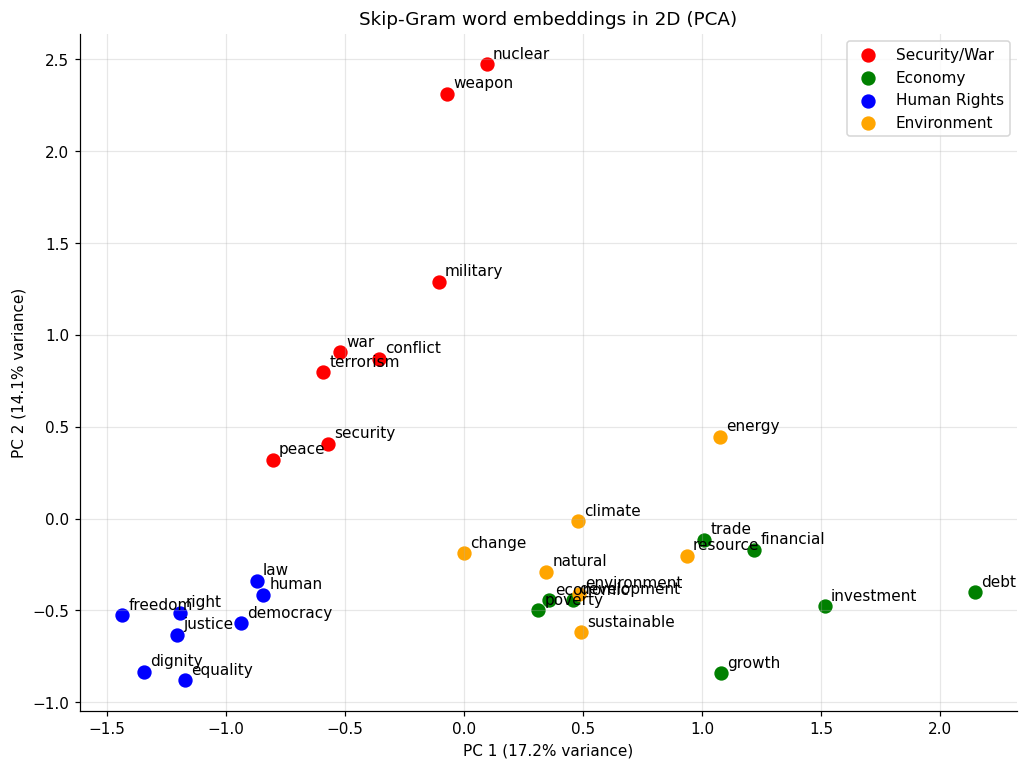

In [24]:
# ---- Plot 1: PCA of a subset of WORD vectors ----
topic_words = {
    'Security/War':   ['war', 'peace', 'security', 'weapon', 'nuclear', 'military', 'conflict', 'terrorism'],
    'Economy':        ['economic', 'trade', 'poverty', 'development', 'debt', 'growth', 'financial', 'investment'],
    'Human Rights':   ['right', 'freedom', 'democracy', 'justice', 'equality', 'human', 'law', 'dignity'],
    'Environment':    ['climate', 'environment', 'energy', 'sustainable', 'resource', 'change', 'natural'],
}
colors = {'Security/War': 'red', 'Economy': 'green', 'Human Rights': 'blue', 'Environment': 'orange'}

plot_words, plot_labels = [], []
for topic, words in topic_words.items():
    for w in words:
        if w in w2v.wv:
            plot_words.append(w)
            plot_labels.append(topic)

word_vecs = np.array([w2v.wv[w] for w in plot_words])
pca_w = PCA(n_components=2, random_state=42)
word_2d = pca_w.fit_transform(word_vecs)

plt.figure(figsize=(11, 8))
for topic in topic_words:
    pts = [i for i, l in enumerate(plot_labels) if l == topic]
    plt.scatter(word_2d[pts, 0], word_2d[pts, 1], c=colors[topic], label=topic, s=70)
for i, w in enumerate(plot_words):
    plt.annotate(w, (word_2d[i, 0], word_2d[i, 1]), fontsize=10, xytext=(4, 4), textcoords='offset points')
plt.title("Skip-Gram word embeddings in 2D (PCA)")
plt.xlabel("PC 1 (%.1f%% variance)" % (pca_w.explained_variance_ratio_[0] * 100))
plt.ylabel("PC 2 (%.1f%% variance)" % (pca_w.explained_variance_ratio_[1] * 100))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

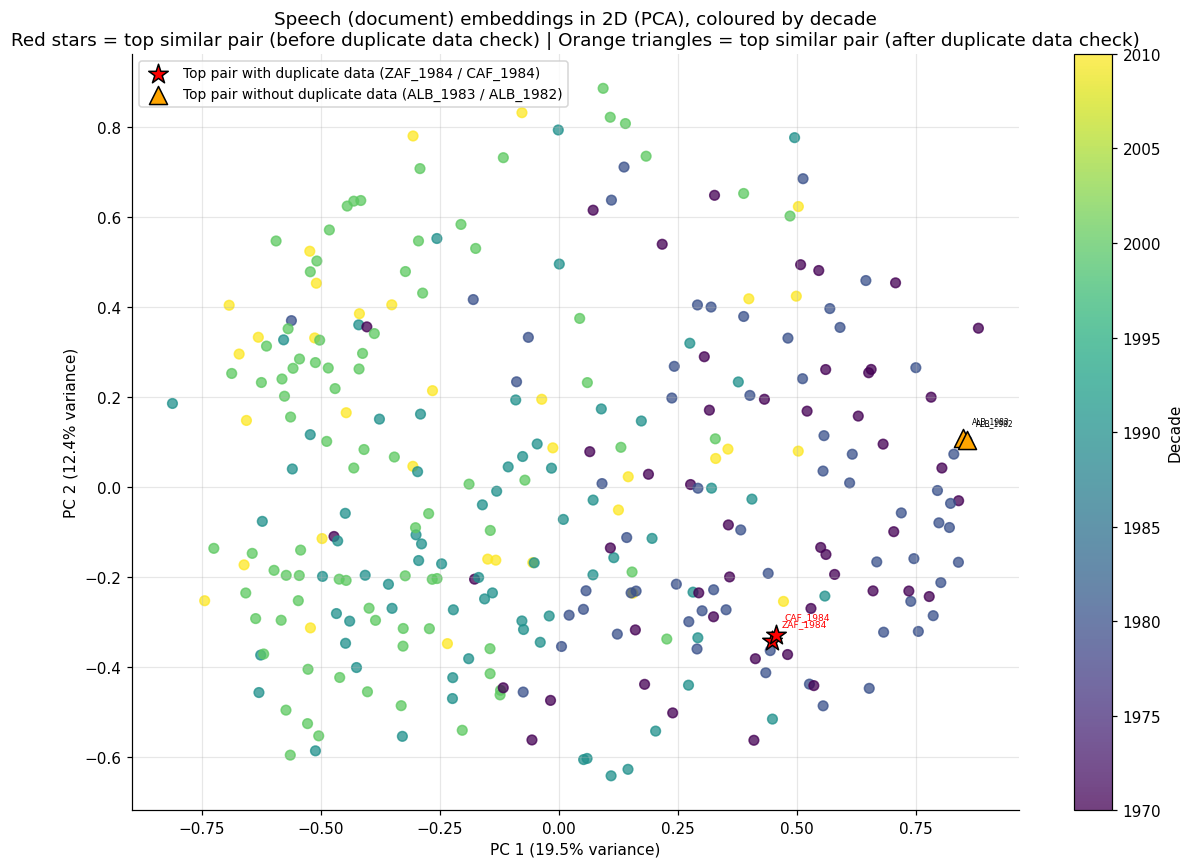

In [25]:
# ---- Plot 2: PCA of a subset of DOCUMENT vectors ----
# Take a random sample of 300 speeches for a readable plot.
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(df), size=300, replace=False);

pca_d = PCA(n_components=2, random_state=42)
doc_2d = pca_d.fit_transform(unit_vectors[sample_idx])

decades = (df['year'].values[sample_idx] // 10) * 10
plt.figure(figsize=(11, 8))
sc = plt.scatter(doc_2d[:, 0], doc_2d[:, 1], c=decades, cmap='viridis', s=40, alpha=0.75)
plt.colorbar(sc, label='Decade')

# Highlight the TOP-1 most similar pair (red stars)
for idx in [rows[0], cols[0]]:
    v = pca_d.transform(unit_vectors[idx].reshape(1, -1))[0]
    plt.scatter(v[0], v[1], c='red', s=180, marker='*', edgecolors='black', zorder=5,
                label='Top pair with duplicate data (ZAF_1984 / CAF_1984)' if idx == rows[0] else None)
    plt.annotate(doc_names[idx], (v[0], v[1]), fontsize=6, color='red',
                 xytext=(6, 10), textcoords='offset points')

# Highlight the TOP-2 most similar pair (orange triangles)
for idx in [rows[1], cols[1]]:
    v = pca_d.transform(unit_vectors[idx].reshape(1, -1))[0]
    plt.scatter(v[0], v[1], c='orange', s=140, marker='^', edgecolors='black', zorder=5,
                label='Top pair without duplicate data (ALB_1983 / ALB_1982)' if idx == rows[1] else None)
    plt.annotate(doc_names[idx], (v[0], v[1]), fontsize=5, color='black',
                 xytext=(6, 10), textcoords='offset points')

plt.legend(loc='best', fontsize=9)
plt.title("Speech (document) embeddings in 2D (PCA), coloured by decade\n"
          "Red stars = top similar pair (before duplicate data check) | Orange triangles = top similar pair (after duplicate data check)")
plt.xlabel("PC 1 (%.1f%% variance)" % (pca_d.explained_variance_ratio_[0] * 100))
plt.ylabel("PC 2 (%.1f%% variance)" % (pca_d.explained_variance_ratio_[1] * 100))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observations on the plots
- **Word plot:** words of the same topic tend to lie close together (e.g. *war, weapon, nuclear, military*). This shows Skip-Gram learned semantic meaning from context. Some overlap is normal because PCA squeezes 100 dimensions into just 2, so some information is lost.
- **Document plot:** speeches from similar periods lie near each other, because world topics change over time (Cold War in the 1970s-80s, terrorism and climate in later years). The two red stars are the most similar pair from the similarity analysis with duplicate data present, and two orange triangles are most similar pair when duplicate data are removed.

---
# Conclusion
1. **Part I:** A bigram model built from all 7,507 speeches recommended the top 3 words to complete *"it is a pleasure ___"* using bigram counts and probabilities. The top three words and their probabilities were: 'to' (33.71%), 'for' (13.03%), and 'in' (12.09%). This model effectively identified the most likely next words, demonstrating that "to" is the most probable, which is grammatically correct and consistent with common phrases in UN speeches.

2. **Part II (i):** Text was tokenized, lowercased, cleaned of stop words, stemmed, and lemmatized. Comparison of vocabulary sizes revealed that stemming reduces vocabulary the most but can produce non-words, while lemmatization retains real words and is chosen for subsequent steps.

3. **Part II (ii):** Skip-Gram embeddings were trained on the lemmatized tokens, and document vectors were created by averaging word vectors. The word embeddings demonstrated semantic meaningfulness, as related words clustered together.

4. **Part II (iii):** Cosine similarity on mean-centered document vectors was used to compare the speeches. The highest-scoring pair, ZAF_1984 and CAF_1984 (cosine 0.9986), turned out to be the same speech stored under two labels, which the shingle-based duplicate check confirmed (text overlap 0.956). Excluding that duplicate, the two most similar documents are ALB_1983 and ALB_1982 (cosine 0.9828). They share only 5% of their three-word phrases, so their similarity comes from shared topics rather than copied text. The PCA plots support this: words from the same topic cluster together, and speeches are arranged roughly by decade.